In [1]:
import json
import time
import logging
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
# Инициализация логгера. Не перезапускать - создастся много логгеров сразу, будут двоить/троить записи!
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

dh = logging.FileHandler('debug.log', encoding='utf-8')
dh.setLevel(logging.DEBUG)

eh = logging.FileHandler('error.log', encoding='utf-8')
eh.setLevel(logging.ERROR)

# Указываем время работы и прочую инфформацию (по дефолту бы меньше сведений было, особенно не хватало бы времени как раз)
formatter = logging.Formatter('%(asctime)s-%(name)s-%(levelname)s-%(message)s')
dh.setFormatter(formatter)
eh.setFormatter(formatter)

logger.addHandler(eh)
logger.addHandler(dh)

In [26]:
with open(r'D:\Личные файлы\Telegram\vacancies_final (3).json', 'r', encoding='utf-8') as file:
    df = pd.read_json(file).set_index('id')
logger.debug(f"Загружен файл, итого {df.shape} строк и столбцов")
df.sample(5)

,query,title,company,salary,description,skills,link
id,,,,,,,
2411,программист+c++,Программист - разработчик встроенного ПО (С++/...,Мера,Не указана,Приглашаем embedded -программиста — профессион...,"[Linux, С#, C++]",https://hh.ru/vacancy/131415044
1120,python+разработчик,Senior Python Developer (ОФИС),Selecty,от 300 000 до 350 000 ₽ за месяц на руки,Вакансия: Senior Python Developer Формат работ...,[],https://hh.ru/vacancy/131294833
990,python+разработчик,Backend-разработчик (Консультации),ОООИнтеллектуал Групп,от 100 000 до 150 000 ₽ за месяц на руки,Подработка для Backend-разработчиков (Консульт...,"[Golang, PostgreSQL, Java, Python, SQL, Git, K...",https://hh.ru/vacancy/131470689
1731,java+разработчик,"Технический интервьюер (Backend, Java / Kotlin)",Wanted,до 50 $ за час на руки,Не найдено,[],https://hh.ru/vacancy/130898436
1712,java+разработчик,Разработчик Java,АОА2М,Не указана,"Мы — крупный финансово-промышленный холдинг, о...",[],https://hh.ru/vacancy/126485872


In [6]:
def parse_salary(x):
    arr = str(x).replace('\xa0', ' ').split(" ")
    arr_idx = [i for i, s in enumerate(arr) if s.isdigit()]
    final = []
    prev=0
    token=""
    for idx in arr_idx:
        if idx == prev+1:
            prev = idx
            token = token + arr[idx]
        else:
            final.append(token)
            prev = idx
            token = arr[idx]
    if len(token)>0:
        final.append(token)
    nums = [int(el) for el in final if el.isdigit()]
    if len(nums)>0:
        return np.average(np.array(nums))
    else:
        return None

In [46]:
df["salary_parced"] = df["salary"].apply(lambda x: parse_salary(x))
logger.debug("Зарплата обработана")

KeyError: 'salary'

In [28]:
df = df.explode("skills", ignore_index=True)
logger.debug(f"Получено {df.shape} денормализированных строк")

In [45]:
df["id"] = df["link"].apply(lambda x: str(x).split("/")[-1])

In [30]:
skillset = df['skills'].dropna().unique()
skillset.sort()
logger.debug(f"Итого уникальных скиллов: {len(skillset)}")

In [31]:
cleaned_skills = [
    'Python', 'JavaScript', 'TypeScript', 'Java', 'C++', 'C', 'Golang', 'Kotlin', 'PHP', 'Bash',
    'Django', 'Flask', 'FastAPI', 'React', 'Vue.js', 'Qt', 'Unity', 'Unreal Engine', 'Selenium', 'JUnit',
    'SQL', 'PostgreSQL', 'MySQL', 'MongoDB', 'Redis', 'Clickhouse', 'NoSQL',
    'REST API', 'gRPC', 'GraphQL', 'WebSockets',    
    'ML', 'Deep Learning', 'LLM', 'PyTorch', 'TensorFlow', 'CV', 'NLP', 
    'OpenCV', 'MLflow', 'Pandas', 'NumPy'
]
len(cleaned_skills)

42

In [32]:
skill_mapping = {
    'Bash': 'Bash',
    'C++': 'C++',
    'C/C++': 'C++',
    'C': 'C',
    'С++': 'C++',
    'С': 'C',
    'Golang': 'Golang',
    'Java': 'Java',
    'JavaScript': 'JavaScript',
    'Kotlin': 'Kotlin',
    'PHP': 'PHP',
    'Python': 'Python',
    'Python/Django': 'Django',
    'TypeScript': 'TypeScript',    
    'Django': 'Django',
    'Django Framework': 'Django',
    'django': 'Django',
    'Django Rest Framework': 'Django',
    'FastAPI': 'FastAPI',
    'Flask': 'Flask',
    'Qt': 'Qt',
    'React': 'React',
    'Unity': 'Unity',
    'Unreal Engine': 'Unreal Engine',
    'Vue.js': 'Vue.js',
    'Selenium': 'Selenium',
    'JUnit': 'JUnit',
    'OpenCV': 'OpenCV',
    'PyTorch': 'PyTorch',
    'TensorFlow': 'TensorFlow',
    'pandas': 'Pandas',
    'Numpy': 'NumPy',
    'MLflow': 'MLflow',
    'SQLAlchemy': 'SQL',
    'SQL': 'SQL',
    'PostgreSQL': 'PostgreSQL',
    'MySQL': 'MySQL',
    'MongoDB': 'MongoDB',
    'Redis': 'Redis',
    'Clickhouse': 'Clickhouse',
    'NoSQL': 'NoSQL',    
    'REST': 'REST API',
    'REST API': 'REST API',
    'gRPC': 'gRPC',
    'API': 'REST API',
    'API integration': 'REST API',
    'AI API': 'REST API', 
    'ML': 'ML',
    'Deep Learning': 'Deep Learning',
    'LLM': 'LLM',
    'Computer Vision': 'CV',
    'Natural Language Processing': 'NLP',
    'NLP основы': 'NLP',
    'ChatGPT': 'LLM',
    'Prompt engineering': 'LLM', 
    'RecSys': 'ML', 
    'Классическое машинное обучение': 'ML',    
    'HTTP': 'REST API',    
   'DWH': "SQL",
 }

In [33]:
df["skill_mapped"] = df["skills"].map(skill_mapping)
df

,query,title,company,salary,description,skills,link,salary_parced,id,skill_mapped
0,python+разработчик,Junior Python-разработчик,КИНЕВА ОКСАНА ЕВГЕНЬЕВНА,от 66 000 до 72 000 ₽ за месяц до вычета налогов,"Это вакансия для тех, кто хочет развиваться в ...",Python,https://hh.ru/vacancy/131699015,69000.0,131699015,Python
1,python+разработчик,Junior Python-разработчик,КИНЕВА ОКСАНА ЕВГЕНЬЕВНА,от 66 000 до 72 000 ₽ за месяц до вычета налогов,"Это вакансия для тех, кто хочет развиваться в ...",SQL,https://hh.ru/vacancy/131699015,69000.0,131699015,SQL
2,python+разработчик,Junior Python-разработчик,КИНЕВА ОКСАНА ЕВГЕНЬЕВНА,от 66 000 до 72 000 ₽ за месяц до вычета налогов,"Это вакансия для тех, кто хочет развиваться в ...",Анализ тестирования,https://hh.ru/vacancy/131699015,69000.0,131699015,NaN
3,python+разработчик,Junior Python-разработчик,КИНЕВА ОКСАНА ЕВГЕНЬЕВНА,от 66 000 до 72 000 ₽ за месяц до вычета налогов,"Это вакансия для тех, кто хочет развиваться в ...",Анализ требований,https://hh.ru/vacancy/131699015,69000.0,131699015,NaN
4,python+разработчик,Junior Python-разработчик,КИНЕВА ОКСАНА ЕВГЕНЬЕВНА,от 66 000 до 72 000 ₽ за месяц до вычета налогов,"Это вакансия для тех, кто хочет развиваться в ...",Пользователь ПК,https://hh.ru/vacancy/131699015,69000.0,131699015,NaN
...,...,...,...,...,...,...,...,...,...,...
14607,программист+c++,Эксперт-аналитик 1С,ПАОРостелеком,Не указана,РТК - Специальные решения - дочернее зависимое...,Аналитика,https://hh.ru/vacancy/131164481,NaN,131164481,NaN
14608,программист+c++,Эксперт-аналитик 1С,ПАОРостелеком,Не указана,РТК - Специальные решения - дочернее зависимое...,Информационные технологии,https://hh.ru/vacancy/131164481,NaN,131164481,NaN
14609,программист+c++,Эксперт-аналитик 1С,ПАОРостелеком,Не указана,РТК - Специальные решения - дочернее зависимое...,Работа с большим объемом информации,https://hh.ru/vacancy/131164481,NaN,131164481,NaN
14610,программист+c++,Эксперт-аналитик 1С,ПАОРостелеком,Не указана,РТК - Специальные решения - дочернее зависимое...,1C: Бухгалтерия,https://hh.ru/vacancy/131164481,NaN,131164481,NaN


In [35]:
df = df.drop(["skills", "salary"], axis=1)

In [36]:
df = df.dropna(subset="skill_mapped")
df = df.drop_duplicates()

In [37]:
df["skill_mapped"].nunique()

40

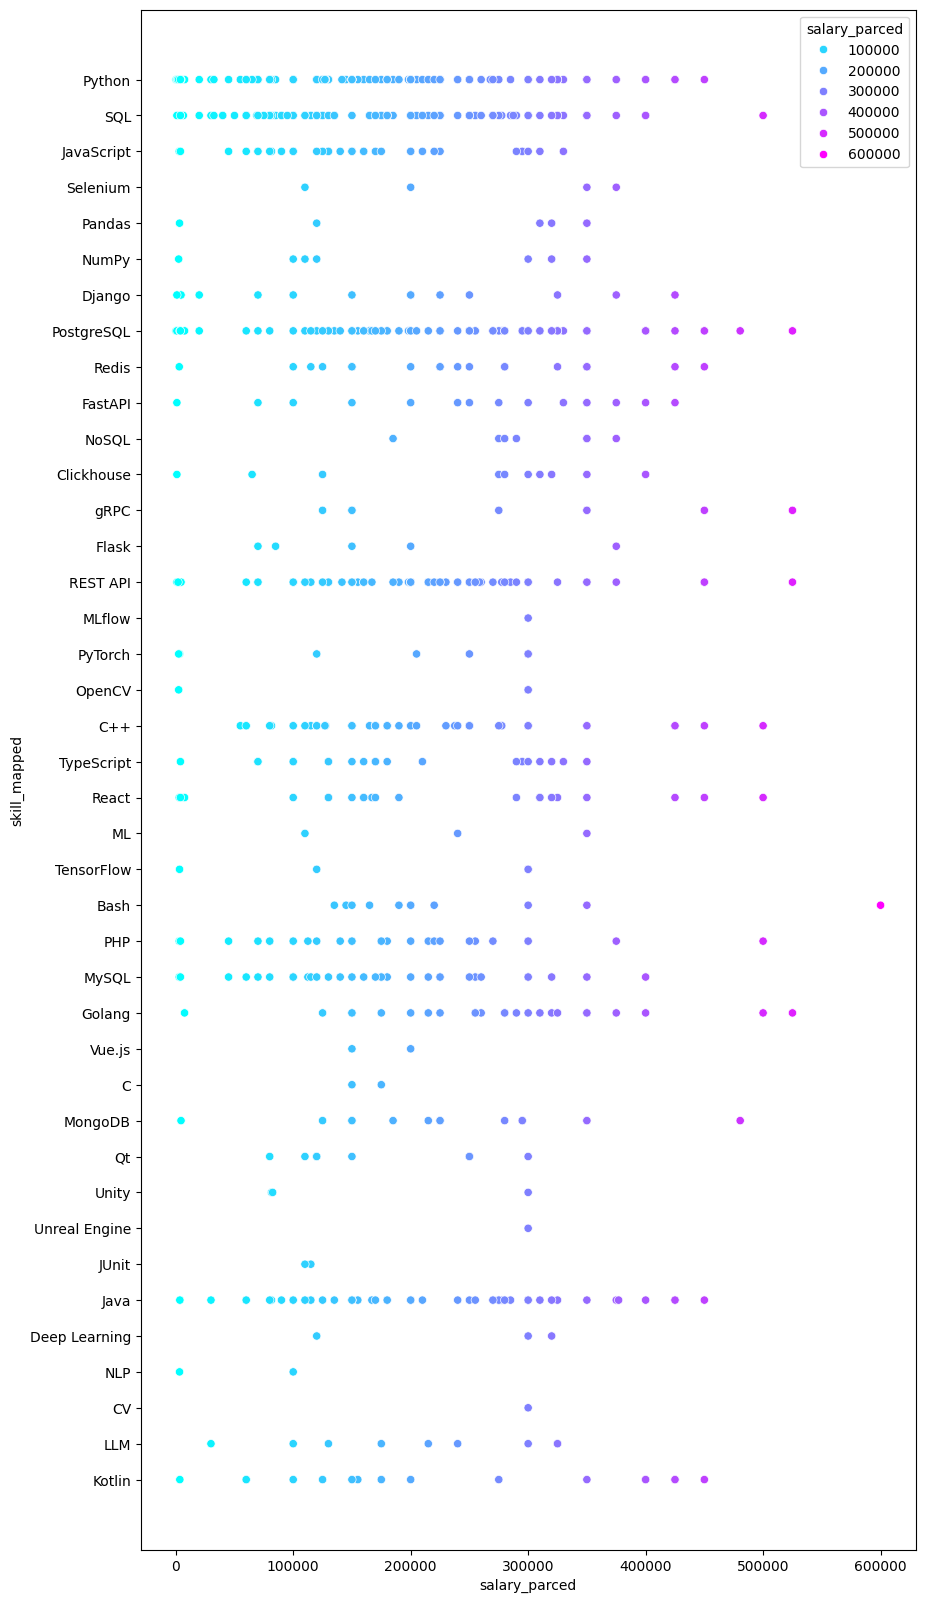

In [38]:
plt.figure(figsize=(10,20))
sns.scatterplot(df, x="salary_parced", y="skill_mapped", palette="cool", hue="salary_parced")
plt.savefig("salary_scatter.png")

<Axes: ylabel='Frequency'>

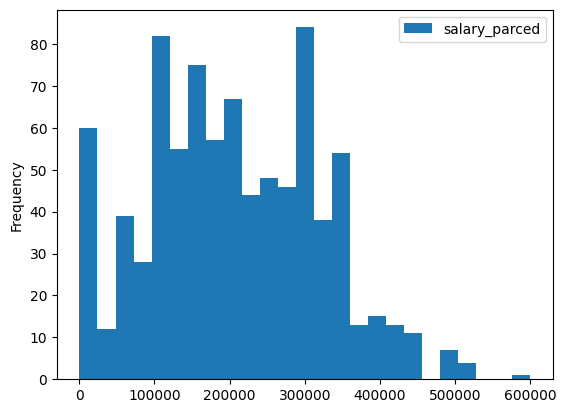

In [39]:
df.plot.hist(bins=25)

In [42]:
hmap_arr = np.array([[0 for i in range(df["skill_mapped"].nunique())] for j in range(df["skill_mapped"].nunique())])
idx_map = {val: key for key, val in enumerate(df["skill_mapped"].unique())}

In [21]:
list_grouped = df.groupby("id")["skill_mapped"].agg(list)

In [43]:
for item in list_grouped:
    for i in range(len(item)):
        for j in range(i+1, len(item)):
            if item[i] in idx_map.keys() and item[j] in idx_map.keys():
                hmap_arr[idx_map[item[i]]][idx_map[item[j]]]+=1
                hmap_arr[idx_map[item[j]]][idx_map[item[i]]]+=1
hmap_arr

array([[  0, 192,  28, ...,   5,  25,   9],
       [192,  42,  18, ...,   1,  10,  10],
       [ 28,  18,   0, ...,   0,   2,   3],
       ...,
       [  5,   1,   0, ...,   0,   1,   0],
       [ 25,  10,   2, ...,   1,   2,   0],
       [  9,  10,   3, ...,   0,   0,   0]], shape=(40, 40))

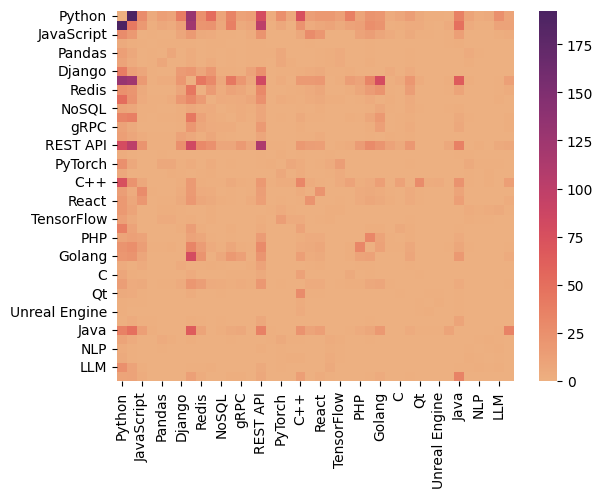

In [44]:
sns.heatmap(pd.DataFrame(hmap_arr, index=idx_map.keys(), columns=idx_map.keys()), cmap="flare")
plt.savefig("library_occurance.png")